# Exercise 4: Long Sales and Revenue Analysis

Uses Polars lazy operations to transform M5 sales to long form, join calendar and prices, calculate revenue, write summaries, and create monthly aggregates for later exercises.

cat_id,total_revenue,mean_revenue,median_revenue,min_revenue,max_revenue,total_sales,mean_sales,median_sales,min_sales,max_sales
str,f64,f64,f64,f64,f64,i64,f64,f64,i64,i64
"""FOODS""",1.0890e8,10.431178,5.94,0.01,2164.32,45089939,4.318836,2.0,1,763
"""HOBBIES""",2.2818e7,9.292119,5.67,0.01,1618.38,6124800,2.494143,1.0,1,294
"""HOUSEHOLD""",5.5954e7,9.895744,6.56,0.02,1766.94,14480670,2.561,2.0,1,626


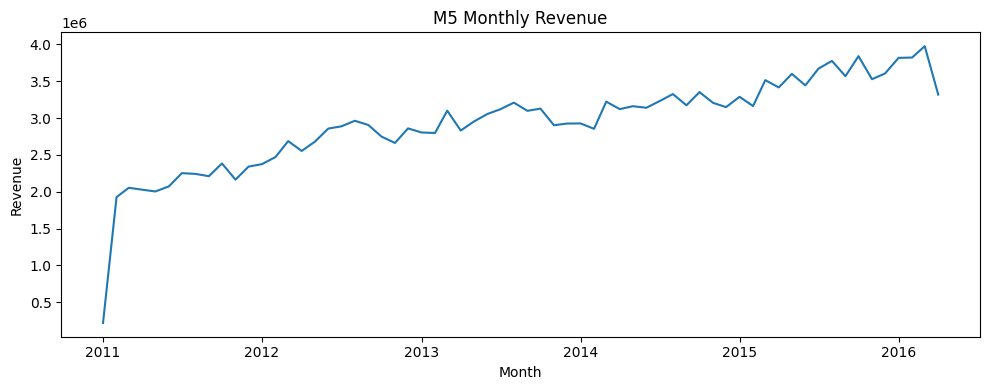

In [1]:
import matplotlib.pyplot as plt
import polars as pl

from tis3il.m5_utils import DOC_ASSETS, PATHS, PROCESSED, ensure_dirs

ensure_dirs()
sales_wide = pl.scan_parquet(PATHS.sales_train)
columns = pl.read_parquet(PATHS.sales_train, n_rows=0).columns
day_cols = [c for c in columns if c.startswith("d_")]
id_cols = [c for c in columns if c not in day_cols]

calendar = pl.scan_parquet(PATHS.calendar).select(
    "d", "date", "wm_yr_wk", "weekday", "month", "year", "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"
)
prices = pl.scan_parquet(PATHS.prices).select("store_id", "item_id", "wm_yr_wk", "sell_price")

def long_sales(include_zero_sales: bool) -> pl.LazyFrame:
    lf = sales_wide.unpivot(index=id_cols, on=day_cols, variable_name="d", value_name="sales")
    if not include_zero_sales:
        lf = lf.filter(pl.col("sales") > 0)
    return lf

positive_sales = (
    long_sales(False)
    .join(calendar, on="d", how="left")
    .join(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
    .with_columns(
        pl.col("sell_price").fill_null(0.0),
        (pl.col("sales") * pl.col("sell_price").fill_null(0.0)).alias("revenue"),
        pl.col("date").cast(pl.Date),
    )
)

positive_sales.sink_parquet(PATHS.sales_enriched)
sales = pl.scan_parquet(PATHS.sales_enriched)

unfiltered = (
    long_sales(True)
    .join(calendar, on="d", how="left")
    .join(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
    .with_columns((pl.col("sales") * pl.col("sell_price").fill_null(0.0)).alias("revenue"))
)

summaries = {
    "revenue_by_year": sales.group_by("year").agg(pl.sum("revenue").alias("total_revenue")).sort("year"),
    "revenue_by_year_store": sales.group_by(["year", "store_id"]).agg(pl.sum("revenue").alias("total_revenue")).sort(["year", "store_id"]),
    "store_year_revenue_filtered": sales.group_by(["store_id", "year"]).agg(pl.sum("revenue").alias("total_revenue"), pl.mean("revenue").alias("mean_revenue"), pl.median("revenue").alias("median_revenue"), pl.min("revenue").alias("min_revenue"), pl.max("revenue").alias("max_revenue")).sort(["store_id", "year"]),
    "store_year_revenue_unfiltered": unfiltered.group_by(["store_id", "year"]).agg(pl.sum("revenue").alias("total_revenue"), pl.mean("revenue").alias("mean_revenue"), pl.median("revenue").alias("median_revenue"), pl.min("revenue").alias("min_revenue"), pl.max("revenue").alias("max_revenue")).sort(["store_id", "year"]),
    "category_summary": sales.group_by("cat_id").agg(pl.sum("revenue").alias("total_revenue"), pl.mean("revenue").alias("mean_revenue"), pl.median("revenue").alias("median_revenue"), pl.min("revenue").alias("min_revenue"), pl.max("revenue").alias("max_revenue"), pl.sum("sales").alias("total_sales"), pl.mean("sales").alias("mean_sales"), pl.median("sales").alias("median_sales"), pl.min("sales").alias("min_sales"), pl.max("sales").alias("max_sales")).sort("cat_id"),
    "top_sales_day": sales.sort("sales", descending=True).limit(1).select("item_id", "store_id", "date", "sales", "revenue"),
    "top_revenue_day": sales.sort("revenue", descending=True).limit(1).select("item_id", "store_id", "date", "sales", "revenue"),
}
for name, lf in summaries.items():
    lf.collect().write_csv(PROCESSED / f"exercise4_{name}.csv")

monthly_dept = sales.with_columns(pl.col("date").dt.truncate("1mo").alias("ds")).group_by(["dept_id", "ds"]).agg(pl.sum("revenue").alias("y"), pl.sum("sales").alias("sales")).rename({"dept_id": "unique_id"}).sort(["unique_id", "ds"])
monthly_top = sales.with_columns(pl.col("date").dt.truncate("1mo").alias("ds")).group_by("ds").agg(pl.sum("revenue").alias("y")).with_columns(pl.lit("Total").alias("unique_id")).select("unique_id", "ds", "y").sort("ds")
monthly_middle = sales.with_columns((pl.col("dept_id") + "_" + pl.col("state_id")).alias("unique_id"), pl.col("date").dt.truncate("1mo").alias("ds")).group_by(["unique_id", "ds"]).agg(pl.sum("revenue").alias("y")).sort(["unique_id", "ds"])
monthly_bottom = sales.with_columns((pl.col("item_id") + "_" + pl.col("store_id")).alias("unique_id"), pl.col("date").dt.truncate("1mo").alias("ds")).group_by(["unique_id", "ds"]).agg(pl.sum("revenue").alias("y")).sort(["unique_id", "ds"])

monthly_dept.collect().write_parquet(PATHS.dept_monthly)
monthly_top.collect().write_parquet(PROCESSED / "top_monthly_revenue.parquet")
monthly_middle.collect().write_parquet(PROCESSED / "middle_monthly_revenue.parquet")
monthly_bottom.collect().write_parquet(PROCESSED / "bottom_monthly_revenue.parquet")

plot_df = monthly_top.collect().to_pandas()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["ds"], plot_df["y"])
ax.set_title("M5 Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
fig.tight_layout()
fig.savefig(DOC_ASSETS / "exercise4_monthly_revenue.png", dpi=150)
summaries["category_summary"].collect()